### Advanced Machine Learning

In [4]:
import sys
print(sys.executable)

c:\Users\N I T R O 5\AppData\Local\Programs\Python\Python312\python.exe


### Imports and Load Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import optuna
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

df = pd.read_csv('D:/Semantic-Ecommerce-Recommender/data/processed/amazon_featured.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (8000, 20)
Columns: ['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth', 'category_name', 'price_capped', 'reviews_capped', 'discount_pct', 'popularity_score', 'value_score', 'title_length', 'combined_text', 'category_encoded']


c:\Users\N I T R O 5\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prepare Features

In [6]:
# Features for advanced ML
feature_cols = ['stars', 'price', 'reviews', 'boughtInLastMonth',
                'discount_pct', 'popularity_score', 'value_score', 'title_length']

# Encode category
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category_name'])

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(df[feature_cols])
y = df['category_encoded']

print(f"Feature matrix shape: {X.shape}")
print(f"Target classes: {len(np.unique(y))}")

Feature matrix shape: (8000, 8)
Target classes: 248


### Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (6400, 8)
Test: (1600, 8)


### Baseline Random Forest

In [8]:
# Baseline RF with default params
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Random Forest Accuracy: {baseline_acc:.4f}")

# Cross validation
cv_scores = cross_val_score(rf_baseline, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Baseline Random Forest Accuracy: 0.0663
5-Fold CV Accuracy: 0.0660 (+/- 0.0037)


### Hyperparameter Tuning with Optima

In [9]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    
    score = cross_val_score(rf, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nBest params: {study.best_params}")
print(f"Best CV accuracy: {study.best_value:.4f}")

Best trial: 17. Best value: 0.103281: 100%|██████████| 20/20 [00:40<00:00,  2.04s/it] 


Best params: {'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 3}
Best CV accuracy: 0.1033


### Train Optimized Model

In [10]:
best_params = study.best_params

rf_optimized = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

rf_optimized.fit(X_train, y_train)
y_pred_optimized = rf_optimized.predict(X_test)
optimized_acc = accuracy_score(y_test, y_pred_optimized)

print(f"Optimized Random Forest Accuracy: {optimized_acc:.4f}")
print(f"Improvement over baseline: {(optimized_acc - baseline_acc)*100:.2f}%")

Optimized Random Forest Accuracy: 0.0969
Improvement over baseline: 3.06%


### Performance Comparison Chart

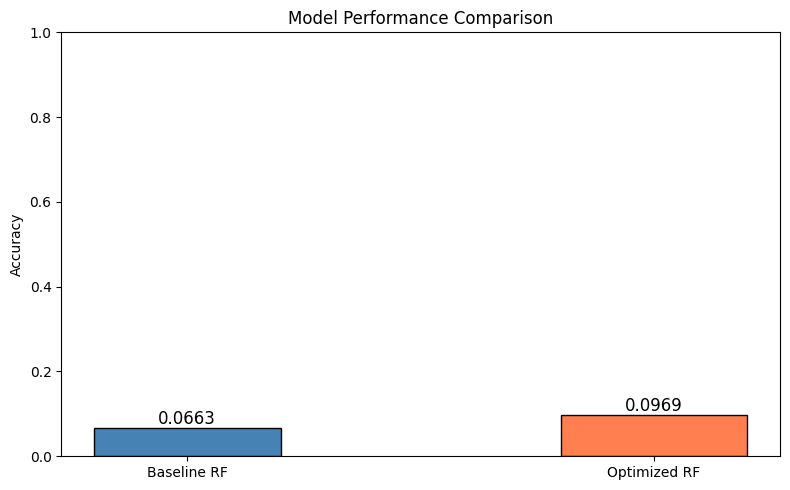

In [11]:
models = ['Baseline RF', 'Optimized RF']
scores = [baseline_acc, optimized_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['steelblue', 'coral'], edgecolor='black', width=0.4)
plt.ylim(0, 1)
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/model_comparison.png')
plt.show()

### Feature Importance Plot

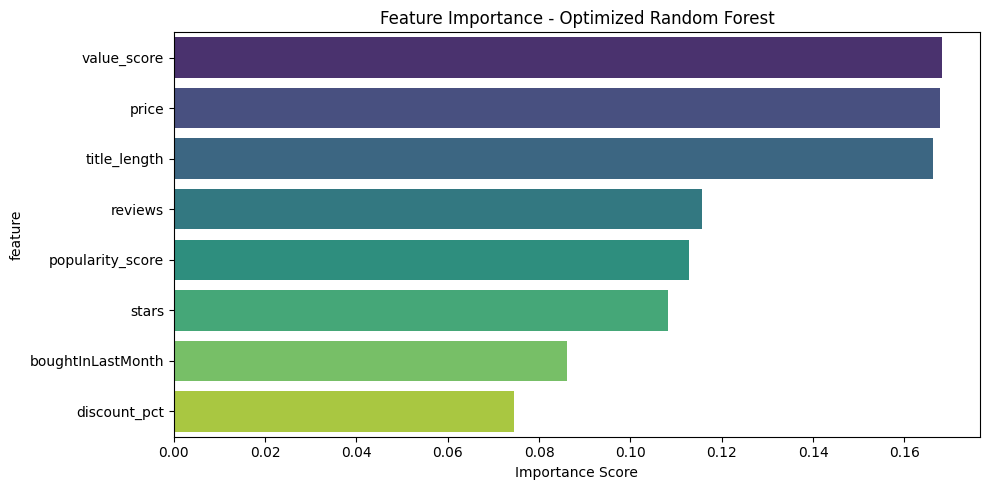

             feature  importance
6        value_score    0.168156
1              price    0.167864
7       title_length    0.166377
2            reviews    0.115686
5   popularity_score    0.112921
0              stars    0.108323
3  boughtInLastMonth    0.086065
4       discount_pct    0.074609


In [12]:
importances = rf_optimized.feature_importances_
feat_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Optimized Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('D:/Semantic-Ecommerce-Recommender/docs/feature_importance_rf.png')
plt.show()

print(feat_importance_df)


### KNN Recommender (Advanced version of Week 3 baseline)

In [17]:
# KNN-based recommender using engineered features
knn = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn.fit(X)

def recommend_knn(product_title, top_n=5):
    # Find the product in the dataset
    match = df[df['title'].str.contains(product_title, case=False, na=False)]
    
    if len(match) == 0:
        print(f"Product '{product_title}' not found.")
        return
    
    product_idx = match.index[0]
    product_vec = X[product_idx].reshape(1, -1)
    
    distances, indices = knn.kneighbors(product_vec)
    
    # Skip first result (the product itself)
    rec_indices = indices[0][1:top_n+1]
    rec_distances = distances[0][1:top_n+1]
    
    results = df.iloc[rec_indices][['title', 'category_name', 'stars', 'price']].copy()
    results['similarity'] = (1 - rec_distances).round(4)
    return results

# Test
print("KNN Recommendations for a Laptop product")
print(recommend_knn("Corsair", top_n=5))

KNN Recommendations for a Laptop product
                                                  title  \
5731  Men's Tactical Sport 2 Mid Side Zip Safety Com...   
6545  Malmö 4-in-1 Canopy Trike with Adjustable Push...   
878    House of the Dead: Overkill - Extended Cut (PS3)   
7752  Cofra 00040-CU8.W11 Thermic Metguard EH PR Saf...   
3706  DEWALT Router, Fixed Base, 1-1/4 HP, 11-Amp, V...   

                                    category_name  stars   price  similarity  
5731                                  Men's Shoes    4.3  119.99      0.9996  
6545                 Tricycles, Scooters & Wagons    4.4  114.99      0.9996  
878   PlayStation 3 Games, Consoles & Accessories    3.6   65.00      0.9991  
7752                                  Men's Shoes    4.5  165.00      0.9990  
3706                     Power Tools & Hand Tools    4.8  146.11      0.9982  


### Saving All Models

In [14]:
os.makedirs('D:/Semantic-Ecommerce-Recommender/models', exist_ok=True)

# Save optimized RF model (this is the main .pkl for Week 7 Streamlit)
joblib.dump(rf_optimized, 'D:/Semantic-Ecommerce-Recommender/models/rf_optimized.pkl')

# Save KNN model
joblib.dump(knn, 'D:/Semantic-Ecommerce-Recommender/models/knn_recommender.pkl')

# Save scaler and encoder
joblib.dump(scaler, 'D:/Semantic-Ecommerce-Recommender/models/scaler.pkl')
joblib.dump(le, 'D:/Semantic-Ecommerce-Recommender/models/label_encoder.pkl')

print("All models saved:")
print("  models/rf_optimized.pkl  ← main model for Streamlit Week 7")
print("  models/knn_recommender.pkl")
print("  models/scaler.pkl")
print("  models/label_encoder.pkl")

All models saved:
  models/rf_optimized.pkl  ← main model for Streamlit Week 7
  models/knn_recommender.pkl
  models/scaler.pkl
  models/label_encoder.pkl


### Summary

In [16]:
print("WEEK 4 SUMMARY")
print(f"Baseline RF Accuracy:   {baseline_acc:.4f}")
print(f"Optimized RF Accuracy:  {optimized_acc:.4f}")
print(f"Best Hyperparameters:   {best_params}")
print(f"Top Feature:            {feat_importance_df.iloc[0]['feature']}")
print(f"Models saved to:        models/")

WEEK 4 SUMMARY
Baseline RF Accuracy:   0.0663
Optimized RF Accuracy:  0.0969
Best Hyperparameters:   {'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 3}
Top Feature:            value_score
Models saved to:        models/
